# Trabajo Adicional: Gestión de Cuadrillas y Órdenes de Trabajo (SmartRoot)

El proyecto **SmartRoot** no solo se encarga de monitorear el potencial mátrico y las variables del suelo. Cuando un sensor reporta un nivel de humedad `crítico`, cuando un tensiómetro requiere relleno de agua, o cuando hay que instalar nuevos sensores Gypsum, el sistema genera **Órdenes de Trabajo (OT)** que deben ser atendidas por **Cuadrillas** de técnicos o agricultores.

En este cuaderno implementaremos el sistema de asignación de OTs y cuadrillas, cumpliendo con los siguientes requerimientos:
1. Modelado usando Programación Orientada a Objetos (POO).
2. Demostración de polimorfismo (métodos con el mismo nombre en diferentes clases).
3. Lógica de asignación, disponibilidad y programación.
4. Propuestas de heurísticas avanzadas.

In [3]:
class Cuadrilla:
    def __init__(self, id_cuadrilla, zona_base, capacidad_diaria_horas):
        self.id_cuadrilla = id_cuadrilla
        self.zona_base = zona_base
        self.capacidad_diaria_horas = capacidad_diaria_horas
        self.ordenes_asignadas = []

    def horas_asignadas(self):
        return sum(ot.duracion_estimada for ot in self.ordenes_asignadas)

    def disponibilidad(self):
        return self.capacidad_diaria_horas - self.horas_asignadas()

    def asignar_ot(self, ot):
        if ot.estado != 'Pendiente':
            print(f'❌ La OT {ot.id_ot} no está Pendiente.')
            return False

        if self.disponibilidad() >= ot.duracion_estimada:
            self.ordenes_asignadas.append(ot)
            ot.estado = 'Asignada'
            print(f'✅ OT {ot.id_ot} asignada a cuadrilla {self.id_cuadrilla}. Disponibilidad restante: {self.disponibilidad()}h')
            return True
        else:
            print(f'⚠️ Cuadrilla {self.id_cuadrilla} sin capacidad para OT {ot.id_ot} (Requiere {ot.duracion_estimada}h, disponible {self.disponibilidad()}h)')
            return False

    def mostrar_programacion(self):
        print(f'\n📅 Programación Cuadrilla {self.id_cuadrilla} (Zona: {self.zona_base})')
        print(f'   Horas capacidad: {self.capacidad_diaria_horas} | Asignadas: {self.horas_asignadas()}')
        print('   ' + '-'*50)
        for ot in sorted(self.ordenes_asignadas, key=lambda x: x.prioridad):
            print(f'   - [{ot.id_ot}] {ot.tipo_ot()} | Prio: {ot.prioridad} | {ot.duracion_estimada}h | ANS: {ot.ans_horas}h')
        print('   ' + '-'*50)

### Clases de Órdenes de Trabajo (Polimorfismo)

A continuación definiremos la clase base abstracta `OrdenTrabajo` y sus clases hijas (`OT_Normal`, `OT_Mantenimiento`, `OT_Urgente`). 

**¿Qué pasa cuando diferentes clases tienen métodos con el mismo nombre pero diferente funcionalidad (Polimorfismo)?**
Al invocar el método (por ejemplo `calcular_costo()` o `ejecutar_accion()`) sobre una lista heterogénea de OTs, Python ejecuta dinámicamente la versión del método que corresponde al tipo real de la instancia. Esto permite escribir código genérico sin necesidad de múltiples bloques `if/elif` evaluando el tipo, facilitando escalar el sistema a decenas de tipos de órdenes distintas.

In [4]:
from abc import ABC, abstractmethod

class OrdenTrabajo(ABC):
    def __init__(self, id_ot, zona, duracion_estimada, prioridad, ans_horas):
        self.id_ot = id_ot
        self.zona = zona
        self.duracion_estimada = duracion_estimada
        self.prioridad = prioridad       # 1=Alta, 2=Media, 3=Baja
        self.ans_horas = ans_horas       # Tiempo máximo esperado
        self.estado = 'Pendiente'

    @abstractmethod
    def tipo_ot(self):
        pass

    @abstractmethod
    def calcular_costo(self, costo_hora_base):
        """Método polimórfico: calculará el costo de manera diferente según el tipo de OT"""
        pass

class OT_Mantenimiento(OrdenTrabajo):
    # Ejemplo: rellenar tensiómetros de agua
    def tipo_ot(self):
        return 'Mantenimiento Preventivo'

    def calcular_costo(self, costo_hora_base):
        # El mantenimiento requiere insumos extra (ej. 15 USD fijos de insumos)
        return (self.duracion_estimada * costo_hora_base) + 15

class OT_Urgente(OrdenTrabajo):
    # Ejemplo: parcela en estrés hídrico extremo, requiere riego inmediato
    def tipo_ot(self):
        return 'Riego Urgente / Crítica'

    def calcular_costo(self, costo_hora_base):
        # Las urgencias pagan hora extra (+50%)
        return self.duracion_estimada * (costo_hora_base * 1.5)

class OT_Instalacion(OrdenTrabajo):
    # Ejemplo: instalar un nuevo sensor Gypsum
    def __init__(self, id_ot, zona, duracion_estimada, prioridad, ans_horas, costo_equipos):
        super().__init__(id_ot, zona, duracion_estimada, prioridad, ans_horas)
        self.costo_equipos = costo_equipos

    def tipo_ot(self):
        return 'Instalación Equipos'

    def calcular_costo(self, costo_hora_base):
        # Instalación requiere técnicos especializados y los equipos mismos
        return (self.duracion_estimada * costo_hora_base * 1.2) + self.costo_equipos


### Asignación de Órdenes usando Heurística Simple (Prioridad y ANS)
A continuación instanciamos las OTs generadas por el sistema SmartRoot y las cuadrillas, y las asignamos automáticamente priorizando las Urgentes.

In [5]:
# 1. Instanciar cuadrillas
cuadrilla_A = Cuadrilla('C-Alfa', zona_base='Sector Norte', capacidad_diaria_horas=8.0)
cuadrilla_B = Cuadrilla('C-Beta', zona_base='Sector Sur', capacidad_diaria_horas=6.0)
cuadrillas = [cuadrilla_A, cuadrilla_B]

# 2. Instanciar OTs (SmartRoot detecta necesidades)
lista_ots = [
    OT_Mantenimiento('OT-001', 'Sector Norte', duracion_estimada=2.0, prioridad=3, ans_horas=48), # Rellenar tensiómetro T42
    OT_Urgente('OT-002', 'Sector Norte', duracion_estimada=3.5, prioridad=1, ans_horas=4),        # Suelo crítico (psi > 400)
    OT_Instalacion('OT-003', 'Sector Sur', duracion_estimada=4.0, prioridad=2, ans_horas=24, costo_equipos=25.0), # Instalar Gypsum
    OT_Urgente('OT-004', 'Sector Sur', duracion_estimada=2.0, prioridad=1, ans_horas=3),          # Falla general de riego
    OT_Mantenimiento('OT-005', 'Sector Sur', duracion_estimada=3.0, prioridad=3, ans_horas=72)
]

# Ordenar las OTs por prioridad (menor número = más prioritario) y ANS (más urgente primero)
ots_priorizadas = sorted(lista_ots, key=lambda x: (x.prioridad, x.ans_horas))

print('⚙️ ASIGNACIÓN AUTOMÁTICA DE OTs')
print('='*50)
for ot in ots_priorizadas:
    # Buscar la cuadrilla de la misma zona con disponibilidad
    cuadrilla_ideal = next((c for c in cuadrillas if c.zona_base == ot.zona and c.disponibilidad() >= ot.duracion_estimada), None)

    # Si la cuadrilla de la zona no tiene disponibilidad, buscar cualquiera que la tenga
    if not cuadrilla_ideal:
        cuadrilla_ideal = next((c for c in cuadrillas if c.disponibilidad() >= ot.duracion_estimada), None)

    if cuadrilla_ideal:
        cuadrilla_ideal.asignar_ot(ot)
    else:
        print(f'🚨 ALERTA: No hay cuadrillas con capacidad para la OT {ot.id_ot} (Prioridad {ot.prioridad})')

print('\n📋 RESULTADO DE LA PROGRAMACIÓN')
for c in cuadrillas:
    c.mostrar_programacion()

print('\n💰 ANÁLISIS DE COSTOS (Demostración de Polimorfismo)')
print('='*50)
costo_hora = 20.0 # USD por hora de técnico
costo_total = 0
for ot in lista_ots:
    costo = ot.calcular_costo(costo_hora)
    costo_total += costo
    print(f'[{ot.id_ot}] {ot.tipo_ot():<25} -> Costo: USD {costo:.2f}')

print('-'*50)
print(f'COSTO TOTAL ESTIMADO DEL DÍA: USD {costo_total:.2f}')

⚙️ ASIGNACIÓN AUTOMÁTICA DE OTs
✅ OT OT-004 asignada a cuadrilla C-Beta. Disponibilidad restante: 4.0h
✅ OT OT-002 asignada a cuadrilla C-Alfa. Disponibilidad restante: 4.5h
✅ OT OT-003 asignada a cuadrilla C-Beta. Disponibilidad restante: 0.0h
✅ OT OT-001 asignada a cuadrilla C-Alfa. Disponibilidad restante: 2.5h
🚨 ALERTA: No hay cuadrillas con capacidad para la OT OT-005 (Prioridad 3)

📋 RESULTADO DE LA PROGRAMACIÓN

📅 Programación Cuadrilla C-Alfa (Zona: Sector Norte)
   Horas capacidad: 8.0 | Asignadas: 5.5
   --------------------------------------------------
   - [OT-002] Riego Urgente / Crítica | Prio: 1 | 3.5h | ANS: 4h
   - [OT-001] Mantenimiento Preventivo | Prio: 3 | 2.0h | ANS: 48h
   --------------------------------------------------

📅 Programación Cuadrilla C-Beta (Zona: Sector Sur)
   Horas capacidad: 6.0 | Asignadas: 6.0
   --------------------------------------------------
   - [OT-004] Riego Urgente / Crítica | Prio: 1 | 2.0h | ANS: 3h
   - [OT-003] Instalación Equip

### Propuesta de Heurísticas Avanzadas

En lugar de usar solo ordenamiento y búsqueda codiciosa (Greedy) por zona y prioridad, para un sistema empresarial más robusto (a medida que las granjas SmartRoot crezcan), se proponen las siguientes heurísticas:

1. **Programación Lineal y OR-Tools:** 
   Modelar el problema como un VRP (Vehicle Routing Problem) o un problema de asignación con ventanas de tiempo (VRPTW). OR-Tools de Google permitiría minimizar simultáneamente los tiempos de viaje de las cuadrillas, los costos por horas extra y el retraso respecto a los ANS, sujeto a restricciones duras de capacidad diaria. 

2. **Simulación de Montecarlo (Cumplimiento de ANS):**
   Las duraciones de instalación o reparación nunca son exactas (Ej. lluvia fuerte, el suelo dificulta instalar el Gypsum, etc). Usar Montecarlo modelando la duración de las OT usando distribuciones normales o triangulares permite responder: *"¿Cuál es la probabilidad de que la Cuadrilla A no logre cumplir el ANS de la OT-002 si el terreno presenta problemas?"*

3. **Optimización Multiobjetivo:**
   El agrónomo quiere reducir los costos (menor horas extra de cuadrillas) pero también maximizar la salud de la planta (atender rápido las OTs Urgentes). Un algoritmo como NSGA-II encontraría frentes de Pareto que balanceen Costo vs Riesgo Hídrico.

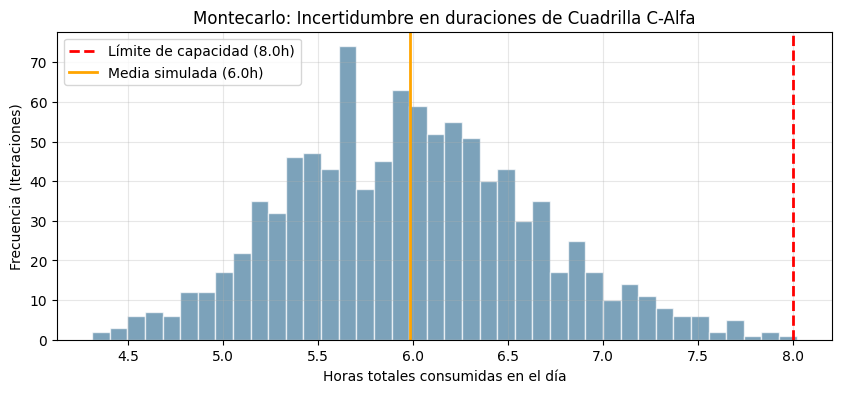

📊 RESULTADOS MONTECARLO (1000 iteraciones):
   Horas estimadas planificadas: 5.5h
   Horas reales promedio     : 6.0h
   Probabilidad de requerir horas extra: 0.1%
   Horas máximas en peor escenario: 8.0h


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación de Montecarlo para el cumplimiento del ANS de la Cuadrilla A
# Variables inciertas: duración real de las OTs asignadas a la Cuadrilla A
iteraciones = 1000
horas_capacidad = cuadrilla_A.capacidad_diaria_horas
horas_estimadas_asignadas = cuadrilla_A.horas_asignadas()

# Supongamos que la duración real de cada OT varía un +/- 25% con distribución triangular
resultados_duracion_total = []

for _ in range(iteraciones):
    duracion_dia = 0
    for ot in cuadrilla_A.ordenes_asignadas:
        minimo = ot.duracion_estimada * 0.75
        maximo = ot.duracion_estimada * 1.50 # Suele demorarse más, no menos
        moda = ot.duracion_estimada
        duracion_real = np.random.triangular(minimo, moda, maximo)
        duracion_dia += duracion_real
    resultados_duracion_total.append(duracion_dia)

resultados_duracion_total = np.array(resultados_duracion_total)
prob_incumplimiento = np.mean(resultados_duracion_total > horas_capacidad) * 100

plt.figure(figsize=(10, 4))
plt.hist(resultados_duracion_total, bins=40, color='#457b9d', alpha=0.7, edgecolor='white')
plt.axvline(horas_capacidad, color='red', linestyle='--', linewidth=2, label=f'Límite de capacidad ({horas_capacidad}h)')
plt.axvline(np.mean(resultados_duracion_total), color='orange', linestyle='-', linewidth=2, label=f'Media simulada ({np.mean(resultados_duracion_total):.1f}h)')

plt.title(f'Montecarlo: Incertidumbre en duraciones de Cuadrilla {cuadrilla_A.id_cuadrilla}')
plt.xlabel('Horas totales consumidas en el día')
plt.ylabel('Frecuencia (Iteraciones)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'📊 RESULTADOS MONTECARLO ({iteraciones} iteraciones):')
print(f'   Horas estimadas planificadas: {horas_estimadas_asignadas:.1f}h')
print(f'   Horas reales promedio     : {np.mean(resultados_duracion_total):.1f}h')
print(f'   Probabilidad de requerir horas extra: {prob_incumplimiento:.1f}%')
print(f'   Horas máximas en peor escenario: {np.max(resultados_duracion_total):.1f}h')
